<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/COPD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Retrieving Census tracts for the entire United States


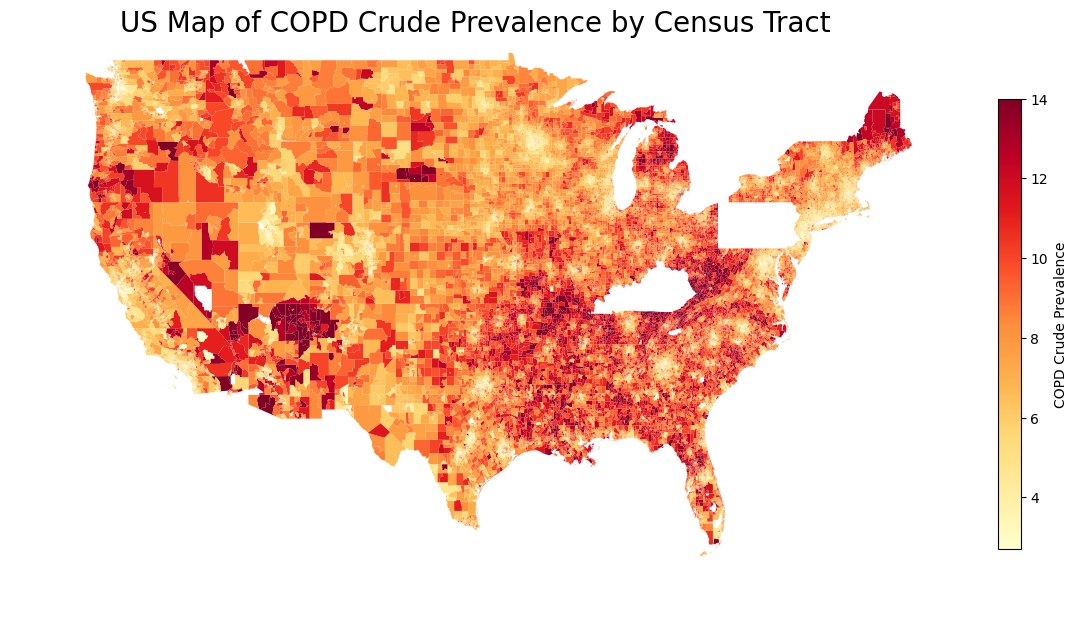

In [ ]:
from matplotlib import legend
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from shapely.geometry import box
!pip install geodatasets
import geodatasets

!pip install pygris
import pygris

gdp = pd.read_csv('/content/PLACES__Census_Tract_Data_(GIS_Friendly_Format),_2025_release_20260610.csv')

gdp['TractFIPS'] = pd.to_numeric(gdp['TractFIPS'], errors='coerce').fillna(0).astype(int)
gdp['TractFIPS'] = gdp['TractFIPS'].astype(str).str.zfill(11)

geo = pygris.tracts(cb=True, year=2023)

#specific rules for geoid
geo['GEOID'] = pd.to_numeric(geo['GEOID'], errors='coerce').fillna(0).astype(int)
geo['GEOID'] = geo['GEOID'].astype(str).str.zfill(11)

#merge map with your data
merged = geo.merge(gdp, left_on='GEOID', right_on='TractFIPS', how='inner')
merged

vmin = merged["COPD_CrudePrev"].quantile(0.02)
vmax = merged["COPD_CrudePrev"].quantile(0.98)

fig, ax = plt.subplots(figsize=(15, 9))

merged.plot(
    column="COPD_CrudePrev",
    cmap="YlOrRd",
    linewidth=0,
    edgecolor="none",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    legend_kwds={"label": "COPD Crude Prevalence", "orientation": "vertical", 'shrink': 0.65},
    ax=ax
)
ax.set_title("US Map of COPD Crude Prevalence by Census Tract", fontsize=20)
ax.axis("off")

ax.set_xlim(-130,-65)
ax.set_ylim(22,50)

plt.show()
